# Projeto Avaliativo - Módulo 1 - Semana 14
 
# Predicting Life Expectancy Using the WHO Health Inequality Data Repository (HIDR)

## Beyond the Numbers: Predicting Life Expectancy from Global Health Inequalities

**Author:** Ananda Christina Staats Pires

**Institution:** Fundamentos de Dados, Programação e Análise Preditiva com Python, SENAI - Programa SCTEC

**Project Type:** End-to-End Machine Learning Regression Pipeline

**Date:** July 2026

## 1. Introduction

Life expectancy is a key indicator of population health and socioeconomic development. It reflects the combined influence of healthcare access, disease burden, environmental exposures, behavioural risk factors, and social determinants of health.

This project develops a supervised machine learning regression pipeline to predict life expectancy using publicly available indicators from the World Health Organization (WHO) Health Inequality Data Repository (HIDR).

Unlike conventional machine learning datasets containing a single pre-processed table, this project integrates multiple WHO thematic datasets into a unified country-year analytical dataset. The workflow includes data acquisition, indicator screening, dataset harmonization, exploratory data analysis, feature preparation, regression modelling, and model evaluation.

The final objective is to investigate how multidimensional health inequality indicators contribute to variations in life expectancy across countries and over time.

## 2. Problem Definition

Life expectancy summarizes the overall health status of populations and is widely used for monitoring health inequalities and supporting evidence-based policy decisions.

The objective of this project is to develop a regression model capable of predicting life expectancy using indicators representing socioeconomic conditions, environmental exposures, behavioural risk factors, and healthcare system characteristics.

By integrating multiple domains of population health, the model aims to provide an interpretable framework for understanding the contribution of different determinants to population health outcomes.

## 3. Project Objectives

### General Objective

Develop an end-to-end machine learning regression pipeline to predict life expectancy using global health indicators from the WHO Health Inequality Data Repository.

### Specific Objectives

- Retrieve health inequality indicators through the WHO HIDR API.
- Screen and select epidemiologically relevant predictors.
- Harmonize heterogeneous datasets into a country-year analytical structure.
- Perform exploratory data analysis and assess data quality.
- Prepare features for regression modelling.
- Train and evaluate predictive models.
- Document the complete workflow following reproducible data science practices.

## 4. Data Source


The data used in this project were obtained from the **World Health Organization (WHO) Health Inequality Data Repository (HIDR)**.

The HIDR is a comprehensive repository of harmonized international health indicators covering multiple dimensions of population health, including health outcomes, healthcare systems, environmental conditions, behavioural risk factors, and socioeconomic determinants.

All datasets were accessed programmatically through the official WHO API, ensuring reproducibility and facilitating future updates as new data become available.

### Citation

> World Health Organization. *Health Inequality Data Repository API*. Geneva: WHO, 2025. Available at: https://www.who.int/data/inequality-monitor/data. Accessed on 09 July 2026.

## 5. Project Structure

The project follows a modular structure in which reusable functions are implemented inside the `src/` directory.

Main modules include:

- `config.py` – project configuration and file paths
- `dataset.py` – dataset download and file management
- `feature_selection.py` – indicator screening and variable selection
- `harmonization.py` – data harmonization and analytical dataset construction
- `visualization.py` – reusable plotting functions
- `preprocessing.py` – preprocessing and feature engineering
- `modeling.py` – model training
- `evaluation.py` – model evaluation

In [56]:
# Configure project paths

import os
import sys
from pathlib import Path

root = Path.cwd()

while not (root / "src").is_dir() and root != root.parent:
    root = root.parent

os.chdir(root)

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"Project root: {root}")

Project root: /Users/anandastaats/who-life-expectancy_prediction


## 5. Import Libraries

The project uses reusable modules implemented in the `src` package together with standard scientific Python libraries.

Separating reusable functions from the notebook improves readability and facilitates future maintenance.

In [57]:
# Import libraries

import numpy as np
import pandas as pd

from IPython.display import display

from src.dataset import (
    load_hidr_dataset,
    dataset_summary,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 6. Download WHO Datasets

The analytical dataset is constructed by integrating multiple thematic datasets from the WHO Health Inequality Data Repository.

Each dataset is downloaded automatically through the reusable data loader. Downloaded files are stored locally and cached to avoid repeated downloads in future executions.

In [58]:
# Download selected WHO HIDR datasets

selected_datasets = {

    "mortality": "rep_gho_mortality",
    "healthcare": "rep_gho_hc",
    "ncd": "rep_gho_ncd",
    "tobacco": "rep_gho_tobacco",
    "alcohol": "rep_gho_alcohol",
    "environment": "rep_gho_env",
    "wash": "rep_wash",
    "poverty": "rep_mpi",
    "world_bank": "rep_wb",
    "development": "rep_gdl2",
}

datasets = {
    name: load_hidr_dataset(dataset_id)
    for name, dataset_id in selected_datasets.items()
}

Loading cached dataset: rep_gho_mortality
Shape: (166980, 24)
Loading cached dataset: rep_gho_hc
Shape: (99976, 24)
Loading cached dataset: rep_gho_ncd
Shape: (625089, 24)
Loading cached dataset: rep_gho_tobacco
Shape: (21882, 24)
Loading cached dataset: rep_gho_alcohol
Shape: (68901, 24)
Loading cached dataset: rep_gho_env
Shape: (138282, 24)
Loading cached dataset: rep_wash
Shape: (136907, 24)
Loading cached dataset: rep_mpi
Shape: (8994, 24)
Loading cached dataset: rep_wb
Shape: (350088, 24)
Loading cached dataset: rep_gdl2
Shape: (608520, 24)


In [59]:
# Summarize downloaded datasets

dataset_summary(datasets)

,Dataset,Rows,Columns
0,ncd,625089,24
1,development,608520,24
2,world_bank,350088,24
3,mortality,166980,24
4,environment,138282,24
5,wash,136907,24
6,healthcare,99976,24
7,alcohol,68901,24
8,tobacco,21882,24
9,poverty,8994,24


## 7. Indicator Screening

The WHO HIDR datasets contain hundreds of indicators covering multiple dimensions of population health.

Before selecting predictors, an initial screening was performed to evaluate indicator availability across countries and years.

The screening considered:

- geographical coverage;
- temporal availability;
- number of observations;
- completeness.

This step supports transparent feature selection before constructing the analytical dataset.

In [60]:
# Calculate indicator coverage

from src.feature_selection import (
    calculate_indicator_coverage,
    display_screening_results,
)


coverage = calculate_indicator_coverage(
    datasets
)

coverage.head()

,dataset,indicator_name,countries,years,observations,missing
0,mortality,Adult mortality rate (probability of dying bet...,185,22,8140,0.00
1,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
2,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
3,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
4,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00


In [61]:
# Display best covered indicators from each dataset

display_screening_results(
    coverage,
    n=10
)

Dataset: alcohol


,dataset,indicator_name,countries,years,observations,missing
234,alcohol,"Alcohol, abstainers in past 12 months (%)",194,21,7859,0.11
245,alcohol,"Alcohol, heavy episodic drinking in past 30 da...",194,21,7858,0.13
246,alcohol,"Alcohol, heavy episodic drinking in past 30 da...",194,21,7858,0.13
235,alcohol,"Alcohol, abstainers lifetime (%)",194,21,7854,0.18
237,alcohol,"Alcohol, consumers in past 12 months (age-stan...",194,21,7854,0.18
239,alcohol,"Alcohol, former drinkers (%)",194,21,7854,0.18
240,alcohol,"Alcohol, harmful use, 12 month prevalence (15+...",194,1,0,100.00
249,alcohol,"Alcohol, per capita consumption (15+ years, am...",191,21,7670,2.44
236,alcohol,"Alcohol, average daily intake among drinkers (...",189,21,7858,0.00
238,alcohol,"Alcohol, current drinkers (youth 15-19 years) (%)",189,2,756,0.00


Dataset: development


,dataset,indicator_name,countries,years,observations,missing
412,development,Expected years of schooling (children aged 6),164,33,55123,0.00
432,development,Life expectancy (years),164,33,55057,0.00
435,development,Mean years of schooling (population aged 25+),164,33,55023,0.00
413,development,Expected years of schooling (children aged 6) ...,164,23,37800,0.00
414,development,Expected years of schooling (children aged 6) ...,164,23,37799,0.00
436,development,Mean years of schooling (population aged 25+) ...,164,23,37749,0.00
437,development,Mean years of schooling (population aged 25+) ...,164,23,37738,0.00
433,development,Life expectancy (years) - Female,163,23,37310,0.00
434,development,Life expectancy (years) - Male,163,23,37310,0.00
422,development,Households with a phone (%),126,32,7587,0.03


Dataset: environment


...

,dataset,indicator_name,countries,years,observations,missing
231,tobacco,Tobacco: current cigarette smoking among adole...,191,19,356,6.81
220,tobacco,"Tobacco, current tobacco use among adolescents...",191,19,282,26.18
216,tobacco,"Tobacco, current tobacco smoking among adolesc...",191,19,208,45.55
224,tobacco,"Tobacco, daily cigarette smoking among adolesc...",191,19,54,85.86
228,tobacco,"Tobacco, daily tobacco smoking among adolescen...",191,19,14,96.34
217,tobacco,"Tobacco, current tobacco smoking among adults ...",190,17,276,27.37
221,tobacco,"Tobacco, current tobacco use among adults (sur...",190,17,210,44.74
232,tobacco,Tobacco: current cigarette smoking among adult...,190,17,210,44.74
229,tobacco,"Tobacco, daily tobacco smoking among adults (s...",190,17,195,48.68
225,tobacco,"Tobacco, daily cigarette smoking among adults ...",190,17,106,72.11


Dataset: wash


,dataset,indicator_name,countries,years,observations,missing
315,wash,Population using basic drinking water services...,173,25,8516,0.00
318,wash,Population using limited drinking water servic...,173,25,8516,0.00
324,wash,Population using unimproved drinking water ser...,173,25,8516,0.00
323,wash,Population using surface water (%),173,25,8278,0.00
317,wash,Population using basic sanitation services (%),171,25,8370,0.00
320,wash,Population using limited sanitation services (%),171,25,8370,0.00
325,wash,Population using unimproved sanitation service...,171,25,8370,0.00
314,wash,Population practising open defecation (%),171,25,8292,0.00
316,wash,Population using basic hygiene services (%),111,25,3346,0.00
326,wash,Population with no hygiene services (%),110,25,3460,0.00


Dataset: world_bank


,dataset,indicator_name,countries,years,observations,missing
379,world_bank,Land area where elevation is below 5 meters (%...,195,3,1170,0.00
387,world_bank,Population living in areas where elevation is ...,195,3,1170,0.00
384,world_bank,Over-age students in primary education (% of e...,193,50,8295,0.18
362,world_bank,"Educational attainment, at least completed low...",191,53,4233,0.12
364,world_bank,"Educational attainment, at least completed pri...",191,50,4010,0.00
388,world_bank,Primary completion rate (% of relevant age group),190,54,9595,0.03
366,world_bank,"Educational attainment, at least completed upp...",189,52,4156,0.00
354,world_bank,Children out of school (% of primary school age),188,54,7534,0.03
390,world_bank,Repeaters of primary education (% of total enr...,188,50,8542,0.00
382,world_bank,Lower secondary completion rate (% of relevant...,186,54,7726,0.05


### Interpretation

The screening step demonstrates substantial variability in indicator availability across WHO HIDR datasets.

Some indicators present broad geographical and temporal coverage, whereas others are limited to specific countries or years.

Coverage assessment is essential because predictors with insufficient availability may substantially reduce the number of observations available for modelling.

The final feature selection therefore considers not only statistical availability, but also epidemiological relevance, interpretability, and redundancy between indicators.

## 8. Feature Selection Strategy

The final predictors were selected based on four criteria:

- epidemiological relevance;
- global availability;
- low redundancy;
- interpretability for public health applications.

The objective was to create a parsimonious regression model capable of capturing multiple dimensions influencing life expectancy.

In [62]:
# Define selected indicators for modelling

selected_features = {

    "development": [
        "Life expectancy (years) ",
        "Expected years of schooling (children aged 6)",
        "Mean years of schooling (population aged 25+)"
    ],

    "poverty": [
        "Multidimensional Poverty Index"
    ],

    "environment": [
        "Concentrations of fine particulate matter (PM2.5)",
        "Population with primary reliance on polluting fuels and technologies for cooking (%)"
    ],

    "wash": [
        "Population using safely managed drinking water services (%)",
        "Population using safely managed sanitation services (%)"
    ],

    "alcohol": [
        "Alcohol, consumers in past 12 months (age-standardized) (%)",
        "Alcohol, per capita consumption (15+ years, among drinkers only) (in litres of pure alcohol)"
    ],

    "tobacco": [
        "Tobacco, current tobacco use prevalence (model-based estimates, age-standardized) (%)"
    ],

    "ncd": [
        "Obesity prevalence among adults, BMI>=30 (age-standardized) (%)"
    ],

    "healthcare": [
        "Medical doctors (%)",
        "Diabetes treatment coverage (30+ years) (age-standardized) (%)",
        "Hypertension treatment coverage among adults aged 30-79 with hypertension (age-standardized) (%)"
    ]
}

In [63]:
# Extract selected indicators

from src.feature_selection import extract_selected_indicators


selected_data = extract_selected_indicators(
    datasets,
    selected_features
)


{
    name: df.shape
    for name, df in selected_data.items()
}

{'development': (165203, 24),
 'poverty': (4497, 24),
 'environment': (17052, 24),
 'wash': (8800, 24),
 'alcohol': (15730, 24),
 'tobacco': (2640, 24),
 'ncd': (12870, 24),
 'healthcare': (27732, 24)}

### Interpretation

The selected indicators represent complementary domains of population health:

- socioeconomic conditions;
- environmental exposures;
- behavioural risk factors;
- healthcare access and disease management.

This multidimensional feature space allows the regression model to capture different pathways influencing life expectancy while maintaining interpretability.

The extracted datasets are now ready for harmonization and construction of the final country-year analytical dataset.

## 9. Dataset Harmonization

The selected WHO indicators originate from multiple thematic repositories.

Although the datasets share a common structure, some indicators are reported according to demographic or geographic subgroups.

Before integration, the datasets must be harmonized into a common country-year structure.

In [64]:
# Inspect reporting dimensions

from src.harmonization import (
    inspect_reporting_dimensions,
    aggregate_subgroups,
    reshape_to_wide,
    merge_datasets,
    rename_variables,
    dataset_quality_summary,
)


inspect_reporting_dimensions(
    selected_data
)

Dataset: development

Indicator: Expected years of schooling (children aged 6)


,dimension,subgroup,observations
335,Subnational region,Central,325
1409,Subnational region,South,243
1070,Subnational region,North,243
517,Subnational region,Eastern,132
1648,Subnational region,Western,132
...,...,...,...
521,Subnational region,Eastern Equatoria,13
1619,Subnational region,Warrap,13
934,Subnational region,Mary,13
1655,Subnational region,Western Equatoria,13



Indicator: Life expectancy (years) 


,dimension,subgroup,observations
335,Subnational region,Central,325
1069,Subnational region,North,243
1408,Subnational region,South,243
517,Subnational region,Eastern,132
1646,Subnational region,Western,132
...,...,...,...
847,Subnational region,Lebap,13
836,Subnational region,Lakes,13
1650,Subnational region,Western Bahr El Ghazal,13
1617,Subnational region,Warrap,13



Indicator: Mean years of schooling (population aged 25+)


...

,dimension,subgroup,observations
0,Sex,Female,6435
1,Sex,Male,6435



Indicator: Hypertension treatment coverage among adults aged 30-79 with hypertension (age-standardized) (%)


,dimension,subgroup,observations
0,Sex,Female,5850
1,Sex,Male,5850



Indicator: Medical doctors (%)


,dimension,subgroup,observations
0,Sex,Female,1581
1,Sex,Male,1581


### Interpretation

The inspection confirms that several WHO indicators are reported according to different population subgroups.

To construct a unified country-year dataset, subgroup estimates must be aggregated before merging datasets.

In [65]:
# Aggregate subgroup estimates

aggregated_data, aggregation_summary = aggregate_subgroups(
    selected_data
)

aggregation_summary

,dataset,indicator_name,observations_before,observations_after,reduction_percent
0,development,Expected years of schooling (children aged 6),55123,5057,90.80
1,development,Life expectancy (years),55057,5057,90.80
2,development,Mean years of schooling (population aged 25+),55023,5052,90.80
3,poverty,Multidimensional Poverty Index,4497,238,94.70
4,environment,Concentrations of fine particulate matter (PM2.5),3860,1950,49.50
5,environment,Population with primary reliance on polluting ...,13192,6596,50.00
6,wash,Population using safely managed drinking water...,4182,2091,50.00
7,wash,Population using safely managed sanitation ser...,4618,2309,50.00
8,alcohol,"Alcohol, consumers in past 12 months (age-stan...",7868,3934,50.00
9,alcohol,"Alcohol, per capita consumption (15+ years, am...",7862,3931,50.00


In [66]:
# Transform datasets into wide format

wide_data = reshape_to_wide(
    aggregated_data
)


{
    name: df.shape
    for name, df in wide_data.items()
}

{'development': (5057, 6),
 'poverty': (238, 4),
 'environment': (6636, 5),
 'wash': (2859, 5),
 'alcohol': (3934, 5),
 'tobacco': (1320, 4),
 'ncd': (6435, 4),
 'healthcare': (6571, 6)}

In [67]:
# Merge datasets

analytical_dataset = merge_datasets(
    wide_data
)


analytical_dataset.shape

(6927, 18)

In [68]:
# Standardize variable names

analytical_dataset = rename_variables(
    analytical_dataset
)


analytical_dataset.head()

,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,1990,3.07,46.06,0.84,NaN,NaN,97.45,NaN,NaN,NaN,NaN,NaN,1.95,22.32,19.10,NaN
1,AFG,Afghanistan,1991,3.37,46.76,0.88,NaN,NaN,97.00,NaN,NaN,NaN,NaN,NaN,2.10,22.36,19.75,NaN
2,AFG,Afghanistan,1992,3.68,47.70,0.92,NaN,NaN,96.25,NaN,NaN,NaN,NaN,NaN,2.27,22.40,20.50,NaN
3,AFG,Afghanistan,1993,3.99,51.57,0.96,NaN,NaN,95.45,NaN,NaN,NaN,NaN,NaN,2.45,22.45,21.20,NaN
4,AFG,Afghanistan,1994,4.29,51.60,1.00,NaN,NaN,94.40,NaN,NaN,NaN,NaN,NaN,2.64,22.50,21.95,NaN


In [69]:
# Assess analytical dataset structure

dataset_quality_summary(
    analytical_dataset
)

,rows,columns,countries,years
0,6927,18,198,45


### Interpretation

The harmonization process successfully transformed multiple WHO HIDR repositories into a unified country-year analytical dataset.

Each observation represents one country in one year, while columns represent selected health, socioeconomic, environmental, behavioural, and healthcare indicators.

This dataset constitutes the foundation for exploratory data analysis, where completeness, distributions, temporal coverage, and relationships between predictors and life expectancy will be evaluated.

In [70]:
# Saving dataset

from src.dataset import save_processed_dataset

save_processed_dataset(
    analytical_dataset
)

Processed dataset saved:
/Users/anandastaats/who-life-expectancy_prediction/data/processed/analytical_dataset.csv


## Phase 1 - Exploratory Data Analysis (EAD)

This phase aims to understand the structure and quality of the harmonized WHO dataset before any preprocessing.

The exploratory analysis focuses on:

- dataset structure and variable types;
- duplicate records and missing values;
- indicator availability across countries and years;
- temporal consistency of the data;
- definition of the modelling dataset;
- exploratory analysis of the target variable;
- relationships between predictors and life expectancy.

The objective is to establish an evidence-based foundation for the preprocessing and modelling stages.

## Dataset structure

The first quality assessment evaluates:

- variable names;
- data types;
- number of observations;
- numerical and categorical variables.

Correct data types are essential for subsequent statistical analysis and machine learning preprocessing.

In [72]:
# Import libraries

import numpy as np
import pandas as pd

from IPython.display import display

# Import project modules

from src.dataset import load_processed_dataset

from src.plots import (
    plot_histogram,
    plot_boxplots,
    plot_scatter,
    plot_correlation_heatmap,
    plot_missing_values,
    plot_indicator_coverage,
    plot_temporal_coverage,
    plot_multiple_histograms,
)

# Display configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [73]:
# Load harmonized analytical dataset

df = load_processed_dataset()

print("=" * 70)
print("ANALYTICAL DATASET OVERVIEW")
print("=" * 70)

# Inspect dataset structure
print(f"Dataset shape: {df.shape}")

print("\nData types:")
display(df.dtypes)

print("\nFirst five observations:")
display(df.head())

# Calculate missing values
print("\nMissing values:")

missing_summary = (
    pd.DataFrame({
        "Missing values": df.isnull().sum(),
        "Percentage (%)": (df.isnull().mean() * 100).round(2)
    })
    .sort_values("Percentage (%)", ascending=False)
)

display(missing_summary)


# Calculate Descriptive statistics 
print("\nDescriptive statistics:")
display(df.describe().T)


# Complete duplicates

n_duplicates = df.duplicated().sum()

print(f"Complete duplicate rows: {n_duplicates}")

# Duplicate country-year observations

n_country_year = df.duplicated(
    subset=["iso3", "date"]
).sum()

print(f"Duplicate country-year observations: {n_country_year}")

if n_country_year > 0:
    display(
        df.loc[
            df.duplicated(
                subset=["iso3", "date"],
                keep=False
            )
        ].sort_values(["iso3", "date"])
    )

Loaded processed dataset: (6927, 18)
ANALYTICAL DATASET OVERVIEW
Dataset shape: (6927, 18)

Data types:


iso3                            str
setting                         str
date                          int64
expected_years_schooling    float64
life_expectancy             float64
mean_years_schooling        float64
mpi                         float64
pm25                        float64
polluting_cooking_fuels     float64
safe_drinking_water         float64
safe_sanitation             float64
alcohol_consumers           float64
alcohol_consumption         float64
tobacco_use                 float64
obesity_prevalence          float64
diabetes_treatment          float64
hypertension_treatment      float64
medical_doctors             float64
dtype: object


First five observations:


,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,1990,3.07,46.06,0.84,NaN,NaN,97.45,NaN,NaN,NaN,NaN,NaN,1.95,22.32,19.10,NaN
1,AFG,Afghanistan,1991,3.37,46.76,0.88,NaN,NaN,97.00,NaN,NaN,NaN,NaN,NaN,2.10,22.36,19.75,NaN
2,AFG,Afghanistan,1992,3.68,47.70,0.92,NaN,NaN,96.25,NaN,NaN,NaN,NaN,NaN,2.27,22.40,20.50,NaN
3,AFG,Afghanistan,1993,3.99,51.57,0.96,NaN,NaN,95.45,NaN,NaN,NaN,NaN,NaN,2.45,22.45,21.20,NaN
4,AFG,Afghanistan,1994,4.29,51.60,1.00,NaN,NaN,94.40,NaN,NaN,NaN,NaN,NaN,2.64,22.50,21.95,NaN



Missing values:


,Missing values,Percentage (%)
mpi,6689,96.56
tobacco_use,5607,80.94
medical_doctors,5346,77.18
pm25,4977,71.85
safe_drinking_water,4836,69.81
safe_sanitation,4618,66.67
alcohol_consumption,3092,44.64
alcohol_consumers,3000,43.31
mean_years_schooling,1875,27.07
life_expectancy,1870,27.00



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
date,"6,927.00","2,006.51",10.22,"1,980.00","1,998.00","2,007.00","2,015.00","2,024.00"
expected_years_schooling,"5,057.00",11.75,3.38,1.64,9.68,11.91,14.30,18.00
life_expectancy,"5,057.00",68.24,9.07,14.13,62.19,69.90,75.06,84.93
mean_years_schooling,"5,052.00",7.28,3.39,0.29,4.52,7.14,10.18,14.85
mpi,238.00,0.16,0.15,0.00,0.02,0.13,0.28,0.63
pm25,"1,950.00",22.62,14.44,4.92,11.15,18.73,29.92,75.91
polluting_cooking_fuels,"6,596.00",38.00,38.88,0.00,0.00,24.30,79.20,100.00
safe_drinking_water,"2,091.00",51.27,27.37,2.88,26.90,50.28,72.75,100.00
safe_sanitation,"2,309.00",44.89,27.12,3.96,21.73,40.91,61.40,100.00
alcohol_consumers,"3,927.00",42.55,24.25,0.73,25.04,43.05,62.73,84.90


Complete duplicate rows: 0
Duplicate country-year observations: 0


### Interpretation

The dataset contains one observation for each country-year combination and no complete duplicate rows or duplicated country-year records were identified, indicating that the data integration process preserved the expected longitudinal structure.

The dataset combines socioeconomic, environmental, behavioural and healthcare indicators associated with life expectancy. Numerical variables are already stored in formats suitable for statistical analysis and predictive modelling.

Missing values are present across several indicators, reflecting differences in international reporting systems rather than random data loss. Their treatment will be addressed during the preprocessing stage.

## Indicator availability

The proportion of available observations was calculated for each indicator to evaluate data completeness.

This analysis supports the identification of variables with sufficient coverage for predictive modelling while highlighting indicators whose extensive missingness may compromise model performance.

In [74]:
coverage = pd.DataFrame({
    "Available observations": df.notna().sum(),
})

coverage["Coverage (%)"] = (
    coverage["Available observations"] / len(df) * 100
).round(2)

coverage = (
    coverage
    .sort_values("Coverage (%)", ascending=False)
)


coverage["Category"] = pd.cut(

    coverage["Coverage (%)"],

    bins=[0,25,50,75,100],

    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],

    include_lowest=True
)

coverage


,Available observations,Coverage (%),Category
iso3,6927,100.00,Very High
date,6927,100.00,Very High
setting,6927,100.00,Very High
polluting_cooking_fuels,6596,95.22,Very High
obesity_prevalence,6435,92.90,Very High
diabetes_treatment,6435,92.90,Very High
hypertension_treatment,5850,84.45,Very High
expected_years_schooling,5057,73.00,High
life_expectancy,5057,73.00,High
mean_years_schooling,5052,72.93,High


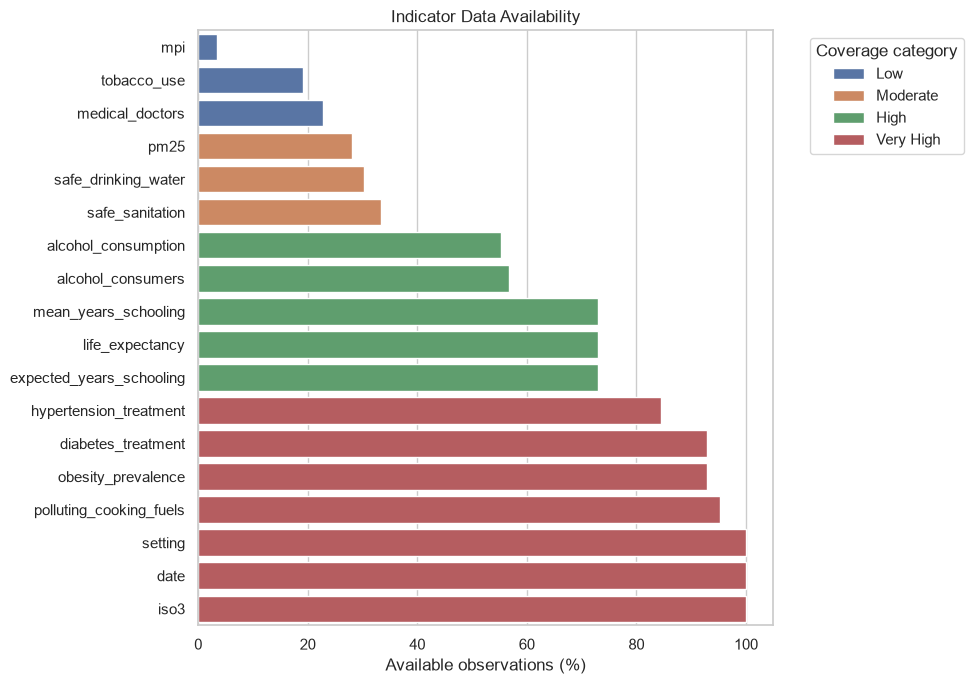

In [75]:
# Plot indicator coverage

plot_indicator_coverage(
    coverage,
    filename="indicator_coverage.png"
)

## Temporal data availability

Overall missingness does not indicate whether indicators are consistently available over time.

Therefore, annual data coverage was examined to identify temporal patterns of availability and determine the period providing the greatest completeness across the selected indicators.

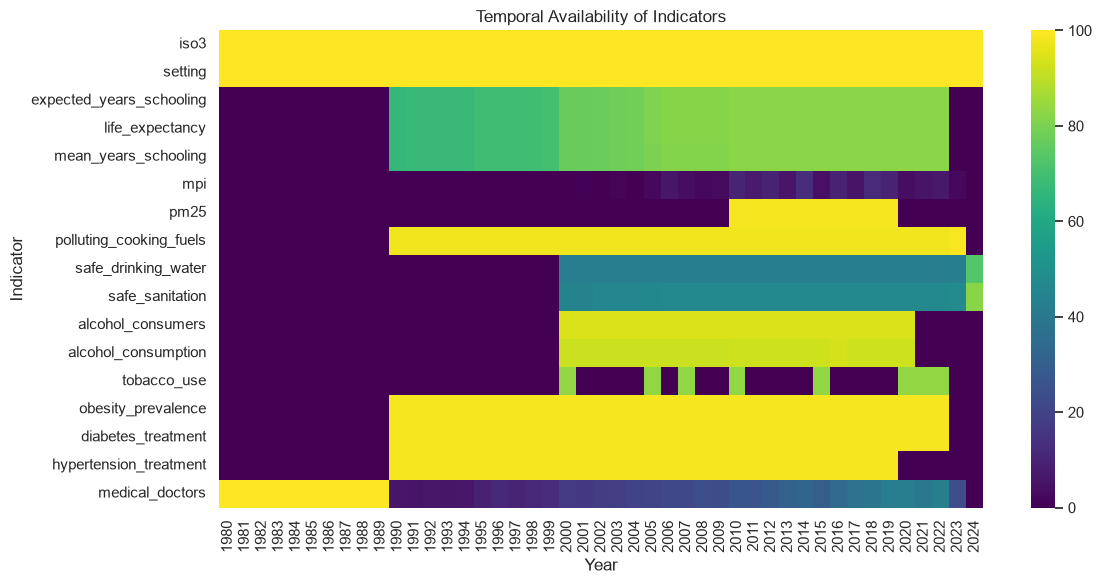

In [76]:
# Prepare temporal coverage matrix

temporal_coverage_matrix = (
    df
    .groupby("date")
    .apply(
        lambda x: x.notna().mean() * 100
    )
    .round(1)
)


temporal_coverage_matrix.head()

plot_temporal_coverage(
    temporal_coverage_matrix,
    filename="temporal_indicator_coverage.png"
)

## EDA-driven modelling decisions

The exploratory analysis was used to define the analytical dataset that will be used throughout the modelling process.

Variable selection considered three complementary criteria:

- indicator availability;
- temporal consistency;
- epidemiological relevance.

Indicators with very limited coverage were excluded from the primary modelling dataset because they would substantially reduce the effective sample size and require extensive imputation.

The analytical period was restricted to 2000–2022, when the selected indicators showed the most consistent availability across countries.

The resulting modelling dataset contains seven predictors and one target variable (life expectancy).

In [77]:
# Define target variable

TARGET = "life_expectancy"

# Define predictor variables

FINAL_PREDICTORS = [
    "obesity_prevalence",
    "diabetes_treatment",
    "polluting_cooking_fuels",
    "hypertension_treatment",
    "mean_years_schooling",
    "expected_years_schooling",
    "alcohol_consumption",
]

# Define analysis period

START_YEAR = 2000
END_YEAR = 2022

# Create modelling dataset
# Keep identifier variables (iso3 and date) for data integrity checks,
# preprocessing and traceability. They will be removed before model training.

model_df = (
    df
    .copy()
    .query("@START_YEAR <= date <= @END_YEAR")
    [
        ["iso3", "date"] +
        FINAL_PREDICTORS +
        [TARGET]
    ]
)

## Modelling dataset overview

After selecting the analytical variables and restricting the study period, the modelling dataset was inspected again.

This second overview confirms the characteristics of the data that will be used during preprocessing and subsequent model development.

In [78]:
# Inspect dataset structure
print(f"Dataset shape: {model_df.shape}")

print("\nData types:")
display(model_df.dtypes)

print("\nFirst five observations:")
display(model_df.head())

# Calculate missing values
print("\nMissing values:")

missing_summary = (
    pd.DataFrame({
        "Missing values": model_df.isnull().sum(),
        "Percentage (%)": (model_df.isnull().mean() * 100).round(2)
    })
    .sort_values("Percentage (%)", ascending=False)
)

display(missing_summary)

print("\nDescriptive statistics:")

# Calculate Descriptive Analisys
descriptive_stats = model_df.describe().T

descriptive_stats["median"] = (
    model_df
    .select_dtypes(include="number")
    .median()
)
display(descriptive_stats)


Dataset shape: (4554, 10)

Data types:


iso3                            str
date                          int64
obesity_prevalence          float64
diabetes_treatment          float64
polluting_cooking_fuels     float64
hypertension_treatment      float64
mean_years_schooling        float64
expected_years_schooling    float64
alcohol_consumption         float64
life_expectancy             float64
dtype: object


First five observations:


,iso3,date,obesity_prevalence,diabetes_treatment,polluting_cooking_fuels,hypertension_treatment,mean_years_schooling,expected_years_schooling,alcohol_consumption,life_expectancy
10,AFG,2000,4.23,22.85,85.15,27.40,1.21,6.12,0.11,55.41
11,AFG,2001,4.58,22.91,82.70,28.45,1.26,6.43,0.11,55.92
12,AFG,2002,4.95,22.97,80.40,29.55,1.31,6.73,0.29,56.57
13,AFG,2003,5.34,23.03,77.97,30.60,1.36,7.04,0.66,57.46
14,AFG,2004,5.77,23.09,75.75,31.75,1.41,7.95,0.83,58.07



Missing values:


,Missing values,Percentage (%)
mean_years_schooling,853,18.73
expected_years_schooling,848,18.62
life_expectancy,848,18.62
alcohol_consumption,719,15.79
hypertension_treatment,654,14.36
polluting_cooking_fuels,92,2.02
obesity_prevalence,69,1.52
diabetes_treatment,69,1.52
iso3,0,0.00
date,0,0.00



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,median
date,"4,554.00","2,011.00",6.63,"2,000.00","2,005.00","2,011.00","2,017.00","2,022.00","2,011.00"
obesity_prevalence,"4,485.00",19.09,13.03,0.30,9.23,17.82,25.09,71.18,17.82
diabetes_treatment,"4,485.00",36.94,15.77,7.02,22.53,38.52,49.06,81.27,38.52
polluting_cooking_fuels,"4,462.00",35.45,37.96,0.00,0.00,17.62,72.59,100.00,17.62
hypertension_treatment,"3,900.00",35.17,15.06,4.55,22.45,36.35,46.60,73.75,36.35
mean_years_schooling,"3,701.00",7.65,3.39,0.80,4.96,7.65,10.61,14.78,7.65
expected_years_schooling,"3,706.00",12.25,3.19,1.64,10.39,12.36,14.75,18.00,12.36
alcohol_consumption,"3,835.00",11.37,6.97,0.02,6.68,11.07,14.56,71.38,11.07
life_expectancy,"3,706.00",69.22,8.68,42.13,63.17,70.80,75.76,84.93,70.80


### Interpretation

The final modelling dataset contains 4,554 country-year observations and eight numerical variables, including seven predictors and the target variable.

Compared with the original dataset, the selected variables present substantially higher data completeness while preserving information from education, healthcare, environmental exposure and behavioural risk factors.

Missing values remain in both predictors and the target variable. Their treatment has intentionally been postponed to the preprocessing stage, where observations with missing target values will be removed and missing predictor values will be imputed using an appropriate strategy.

## Distribution of the target variable

The distribution of life expectancy is evaluated to examine its central tendency, variability and degree of asymmetry.

Understanding the distribution of the response variable helps determine whether transformation is required before model development.

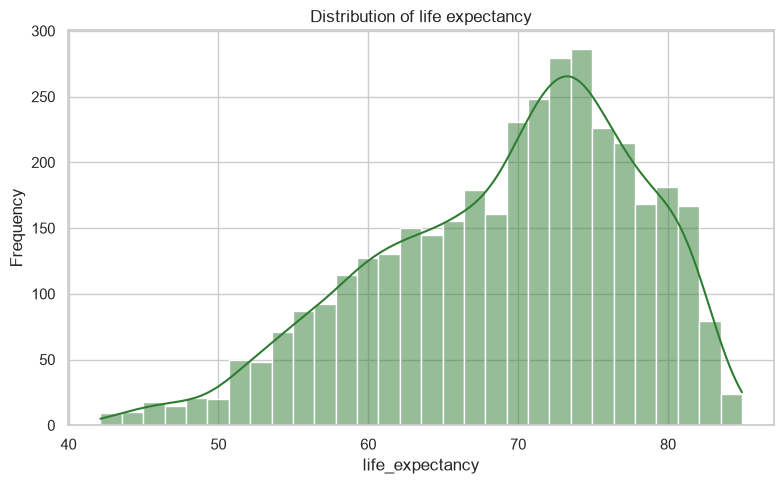

Skewness of life expectancy: -0.57
Median: 70.80 | Mean: 69.22


In [79]:
# Distribution of the target variable

plot_histogram(
    model_df["life_expectancy"],
    "Distribution of life expectancy",
    "04_life_expectancy_distribution.png"
)


print(
    f"Skewness of life expectancy: {model_df['life_expectancy'].skew():.2f}"
)

print(
    f"Median: {model_df['life_expectancy'].median():.2f} | "
    f"Mean: {model_df['life_expectancy'].mean():.2f}"
)

### Interpretation

Life expectancy presented a moderately left-skewed distribution (skewness = −0.57), with the median (70.80 years) slightly higher than the mean (69.22 years).

The lower tail reflects countries with substantially lower life expectancy, which is expected in a global health dataset and represents meaningful variation rather than data anomalies.

No severe asymmetry or extreme values were observed that would justify transforming the response variable. Therefore, life expectancy will be retained on its original scale throughout model development.

## Correlation analysis

Pearson correlation coefficients are calculated to explore the relationships between the selected predictors and life expectancy.

This analysis provides an initial indication of potentially informative predictors while identifying highly correlated variables that may lead to multicollinearity in linear regression models.

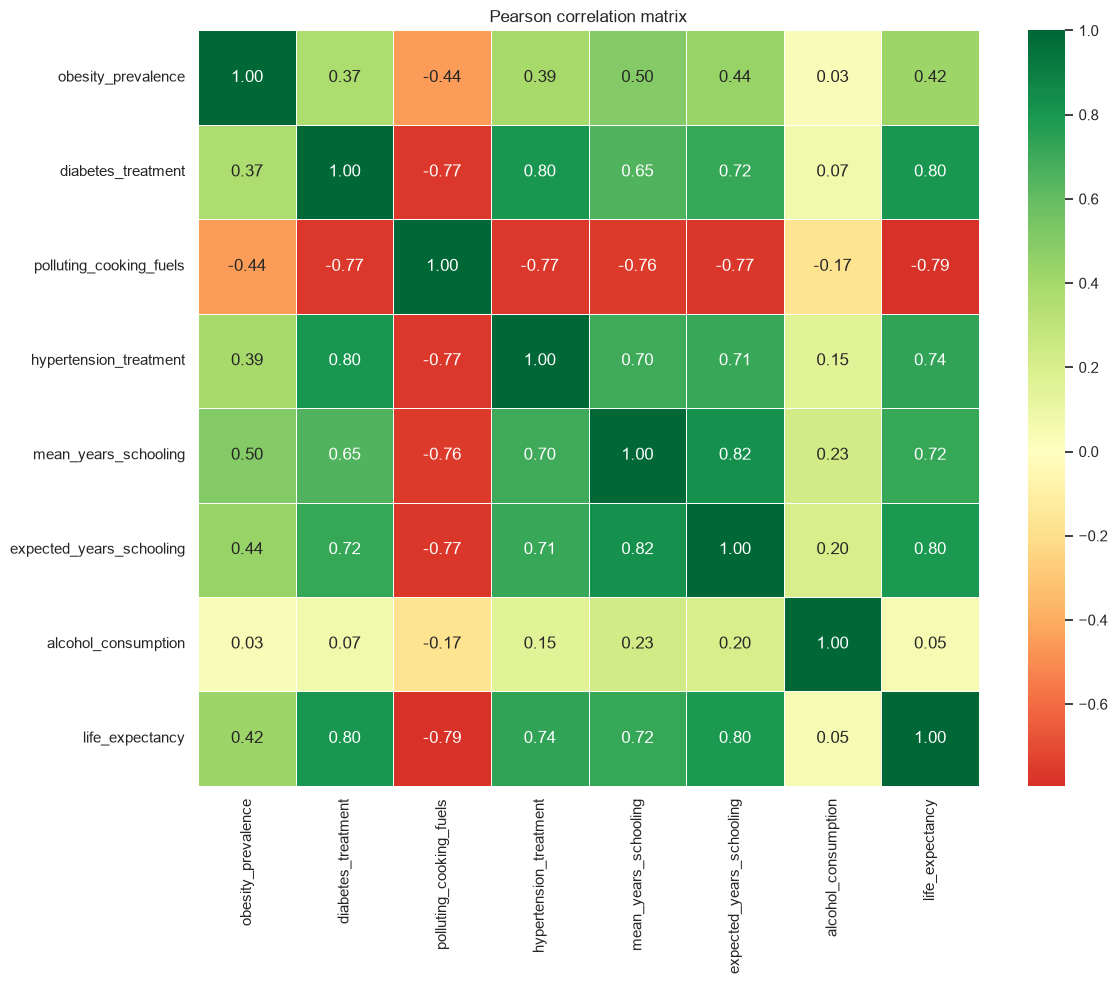

Pairs with correlation > 0.7:


mean_years_schooling      expected_years_schooling    0.82
diabetes_treatment        life_expectancy             0.80
                          hypertension_treatment      0.80
expected_years_schooling  life_expectancy             0.80
hypertension_treatment    life_expectancy             0.74
mean_years_schooling      life_expectancy             0.72
diabetes_treatment        expected_years_schooling    0.72
hypertension_treatment    expected_years_schooling    0.71
polluting_cooking_fuels   mean_years_schooling       -0.76
diabetes_treatment        polluting_cooking_fuels    -0.77
polluting_cooking_fuels   hypertension_treatment     -0.77
                          expected_years_schooling   -0.77
                          life_expectancy            -0.79
dtype: float64

In [80]:
# Correlation matrix among modelling variables

corr_cols = (
    FINAL_PREDICTORS
    +
    ["life_expectancy"]
)


plot_correlation_heatmap(
    model_df[corr_cols],
    filename="05_correlation_heatmap.png"
)


corr = model_df[corr_cols].corr()


pairs = (
    corr
    .where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
)


print(
    "Pairs with correlation > 0.7:"
)


display(
    pairs[
        pairs.abs() > 0.7
    ]
    .sort_values(
        ascending=False
    )
)

### Interpretation

Several predictors showed strong associations with life expectancy.

Educational indicators (mean and expected years of schooling), diabetes treatment, hypertension treatment and polluting cooking fuels presented the strongest correlations with the target variable, suggesting that these variables are likely to contribute substantially to predictive performance.

The correlation matrix also revealed strong correlations among some predictors, particularly between the two education indicators and among healthcare-related variables. These relationships suggest potential multicollinearity and will be formally evaluated during model preparation using Variance Inflation Factor (VIF).

## Critical findings (Phase 1)

The exploratory data analysis established the basis for defining the modelling dataset and the subsequent preprocessing strategy.

The main findings are summarized below:

- **The original harmonized dataset contains one observation per country-year**, with no complete duplicate records or duplicated country-year combinations, confirming the integrity of the longitudinal dataset.

- **Indicator availability varied substantially across the WHO indicators.** Variables with less than 50% coverage were excluded because their extensive missingness would considerably reduce the effective sample size and require substantial imputation.

- **Restricting the analysis to the 2000–2022 period** substantially improved data completeness while preserving a large analytical sample of 4,554 country-year observations.

- **The final modelling dataset comprises seven predictors** representing education, healthcare, environmental exposure and behavioural risk factors, together with life expectancy as the response variable.

- **Life expectancy presented only moderate negative skewness** (skewness = −0.57), indicating that no transformation of the target variable is required.

- **Several predictors showed strong correlations with life expectancy**, suggesting that they are promising candidate predictors for regression modelling.

- **Strong correlations were also identified among some predictors**, particularly within education and healthcare indicators, indicating that multicollinearity should be formally assessed before fitting linear regression models.

- **The modelling dataset (`model_df`) was therefore defined but intentionally left unprocessed.** Missing values and preprocessing operations will be addressed in Phase 2 before model training.

# Fase 2 - Tratamento e Limpeza (Data Prep)

Nesta etapa serão aplicadas as etapas necessárias para preparar o dataset para a modelagem preditiva.

As análises da Fase 1 demonstraram que:

- não foram identificadas duplicatas completas ou registros repetidos de país-ano;
- existem valores ausentes devido à integração de diferentes indicadores internacionais;
- algumas variáveis apresentam distribuições assimétricas e possíveis valores extremos.

O tratamento seguirá três etapas principais:

1. Avaliação de duplicatas;
2. Tratamento de valores ausentes;
3. Avaliação e gerenciamento de outliers nas variáveis preditoras.

As decisões de processamento serão realizadas considerando o objetivo do modelo: prever a expectativa de vida (`life_expectancy`).

In [81]:
# Complete duplicate rows

n_duplicates = model_df.duplicated().sum()

print(f"Complete duplicate rows: {n_duplicates}")


# Duplicate country-year observations

n_country_year = model_df.duplicated(
    subset=["iso3", "date"]
).sum()

print(f"Duplicate country-year observations: {n_country_year}")

Complete duplicate rows: 0
Duplicate country-year observations: 0


In [82]:
# Missing values before treatment

print("Missing values and skewness by variable:")

# Missing values summary
missing_summary = (
    pd.DataFrame({
        "Missing values": model_df.isna().sum(),
        "Missing (%)": (
            model_df.isna().mean() * 100
        ).round(2)
    })
)

# Calculate skewness only for numeric variables
predictor_skewness = (
    model_df
    .select_dtypes(include="number")
    .skew()
    .rename("Skewness")
)

# Combine information
data_quality_summary = (
    missing_summary
    .join(predictor_skewness)
    .sort_values(
        "Missing (%)",
        ascending=False
    )
)

display(data_quality_summary)

Missing values and skewness by variable:


,Missing values,Missing (%),Skewness
mean_years_schooling,853,18.73,-0.06
expected_years_schooling,848,18.62,-0.37
life_expectancy,848,18.62,-0.57
alcohol_consumption,719,15.79,1.81
hypertension_treatment,654,14.36,0.02
polluting_cooking_fuels,92,2.02,0.54
obesity_prevalence,69,1.52,1.27
diabetes_treatment,69,1.52,0.09
iso3,0,0.00,NaN
date,0,0.00,0.00


In [83]:
# Missing value treatment

# Remove observations without target values
initial_rows = len(model_df)

model_df = model_df.dropna(
    subset=[TARGET]
)

removed_rows = initial_rows - len(model_df)

print(
    f"Rows removed due to missing target ({TARGET}): {removed_rows}"
)




# Median imputation for predictor variables
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

model_df[FINAL_PREDICTORS] = (
    imputer.fit_transform(
        model_df[FINAL_PREDICTORS]
    )
)


# Verify remaining missing values

print("Remaining missing values:")

display(
    model_df.isna().sum()
)


Rows removed due to missing target (life_expectancy): 848
Remaining missing values:


iso3                        0
date                        0
obesity_prevalence          0
diabetes_treatment          0
polluting_cooking_fuels     0
hypertension_treatment      0
mean_years_schooling        0
expected_years_schooling    0
alcohol_consumption         0
life_expectancy             0
dtype: int64

### Missing value treatment

Observations without the target variable (`life_expectancy`) were removed because supervised learning requires known outcome values.

Missing values among predictor variables were replaced using median imputation.

The median was selected because health indicators present heterogeneous distributions and potential extreme observations. Compared with mean imputation, the median is less affected by skewed distributions and outliers.

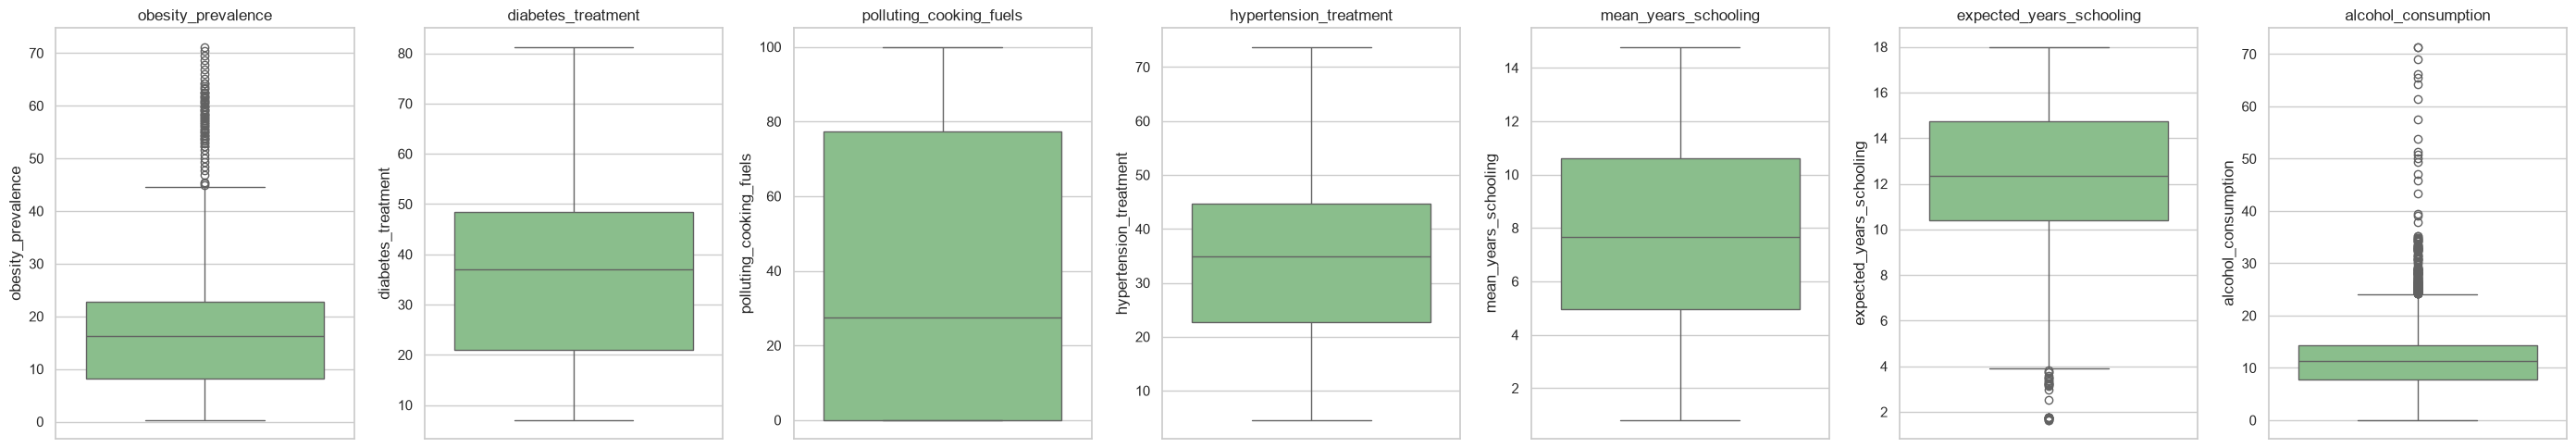

In [84]:
# Boxplots for predictor variables

plot_boxplots(
    model_df,
    FINAL_PREDICTORS,
    filename="06_predictor_boxplots.png"
)

In [85]:
def detect_iqr_outliers(df, columns):

    results = []

    for col in columns:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        n_outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        ).sum()

        results.append(
            {
                "Variable": col,
                "Lower limit": round(lower,2),
                "Upper limit": round(upper,2),
                "Outliers": n_outliers
            }
        )

    return pd.DataFrame(results)


iqr_results = detect_iqr_outliers(
    model_df,
    FINAL_PREDICTORS
)


display(iqr_results)

,Variable,Lower limit,Upper limit,Outliers
0,obesity_prevalence,-13.82,44.69,72
1,diabetes_treatment,-19.99,89.34,0
2,polluting_cooking_fuels,-116.18,193.62,0
3,hypertension_treatment,-10.08,77.47,0
4,mean_years_schooling,-3.50,19.07,0
5,expected_years_schooling,3.86,21.28,28
6,alcohol_consumption,-1.86,24.05,173


### Outlier management

Potential outliers were identified using the Interquartile Range (IQR) method.

Extreme observations were detected mainly in obesity prevalence, expected years of schooling, and alcohol consumption.

However, these observations were maintained because they represent plausible epidemiological differences between countries rather than data collection errors.

Removing these observations could reduce the variability of the dataset and limit the model's ability to capture global health inequalities.

Alternative strategies, including logarithmic transformations and sensitivity analyses excluding extreme observations, will be evaluated during model development.

In [87]:
# Verify cleaned dataset

print("=" * 60)
print("PHASE 2 - CLEAN DATASET SUMMARY")
print("=" * 60)

print(f"Dataset shape: {model_df.shape}")

print("\nRemaining missing values:")
display(model_df.isna().sum())

print("\nData types:")
display(model_df.dtypes)

print("\nFirst five observations:")
display(model_df.head())


# Save cleaned dataset

from src.dataset import save_processed_data
save_processed_data(
    model_df,
    filename="model_df_clean.csv"
)

PHASE 2 - CLEAN DATASET SUMMARY
Dataset shape: (3706, 10)

Remaining missing values:


iso3                        0
date                        0
obesity_prevalence          0
diabetes_treatment          0
polluting_cooking_fuels     0
hypertension_treatment      0
mean_years_schooling        0
expected_years_schooling    0
alcohol_consumption         0
life_expectancy             0
dtype: int64


Data types:


iso3                            str
date                          int64
obesity_prevalence          float64
diabetes_treatment          float64
polluting_cooking_fuels     float64
hypertension_treatment      float64
mean_years_schooling        float64
expected_years_schooling    float64
alcohol_consumption         float64
life_expectancy             float64
dtype: object


First five observations:


,iso3,date,obesity_prevalence,diabetes_treatment,polluting_cooking_fuels,hypertension_treatment,mean_years_schooling,expected_years_schooling,alcohol_consumption,life_expectancy
10,AFG,2000,4.23,22.85,85.15,27.40,1.21,6.12,0.11,55.41
11,AFG,2001,4.58,22.91,82.70,28.45,1.26,6.43,0.11,55.92
12,AFG,2002,4.95,22.97,80.40,29.55,1.31,6.73,0.29,56.57
13,AFG,2003,5.34,23.03,77.97,30.60,1.36,7.04,0.66,57.46
14,AFG,2004,5.77,23.09,75.75,31.75,1.41,7.95,0.83,58.07


Processed dataset saved to: data/processed/model_df_clean.csv
